quick notebook to compare how timezone formatting changes accuracy + loss

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# All models (excluding broken qwen3-235b)
NON_REASONING_MODELS = ['gpt-4o', 'claude-haiku-4-5', 'qwen-coder', 'llama-4']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

# Conditions mapped to subdirectories
CONDITIONS = {
    'regular':   'results',
    'no_guide':  'results_no_guide',
    'math_only': 'results_math_only',
}

# Nice display names & colors
MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'claude-haiku-4-5': 'Claude-Haiku-4.5',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B-Think ★',
    'qwen3-next-thinking': 'Qwen3-Next-Think ★',
}

# MODEL_COLORS = {
#     'gpt-4o': '#1f77b4',
#     'qwen-coder': '#ff7f0e',
#     'llama-4': '#2ca02c',
#     'gpt-5.2': '#d62728',
#     'deepseek-v3.1': '#9467bd',
#     'qwen3-235b-thinking': '#8c564b',
#     'qwen3-next-thinking': '#e377c2',
# }

print(f"Non-reasoning models: {NON_REASONING_MODELS}")
print(f"Reasoning models:     {REASONING_MODELS}")

Non-reasoning models: ['gpt-4o', 'claude-haiku-4-5', 'qwen-coder', 'llama-4']
Reasoning models:     ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']


In [2]:
# load old and new timezone results

BASE_V1 = Path("full_results_timezone_v1")
BASE_NEW = Path("full_results")

# Subdirs: (condition_key, output_subdir_name)
CONDITION_SUBDIRS = [
    ("regular", "results"),
    ("no_guide", "results_no_guide"),
    ("math_only", "results_math_only"),
]

def load_timezone_converted(base: Path, version_label: str) -> pd.DataFrame:
    """Load all timezone*converted*.tsv under base/{results,results_no_guide,results_math_only}/model/."""
    frames = []
    for cond_key, subdir in CONDITION_SUBDIRS:
        pattern = "timezone_converted.tsv" if subdir == "results" else f"timezone_{subdir.replace('results_', '')}_converted.tsv"
        cond_dir = base / subdir
        if not cond_dir.exists():
            continue
        for model_dir in cond_dir.iterdir():
            if not model_dir.is_dir():
                continue
            tsv = model_dir / pattern
            if not tsv.exists():
                continue
            df = pd.read_csv(tsv, sep="\t")
            df["model"] = model_dir.name
            df["condition"] = cond_key
            df["version"] = version_label
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

df_timezone_v1 = load_timezone_converted(BASE_V1, "v1")
df_timezone_new = load_timezone_converted(BASE_NEW, "new")

print(f"v1:  {len(df_timezone_v1):,} rows, models: {sorted(df_timezone_v1['model'].unique()) if len(df_timezone_v1) else []}")
print(f"new: {len(df_timezone_new):,} rows, models: {sorted(df_timezone_new['model'].unique()) if len(df_timezone_new) else []}")


v1:  136,800 rows, models: ['deepseek-v3.1', 'gpt-4o', 'gpt-5.2', 'llama-4', 'qwen-coder', 'qwen3-235b', 'qwen3-235b-thinking', 'qwen3-next-thinking']
new: 194,400 rows, models: ['deepseek-v3.1', 'gpt-4o', 'gpt-5.2', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking']


In [ ]:
df_timezone_v1.head()

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,call_seconds,model,condition,version
0,timezone,NaN,Convert 1AM in Los Angeles time to New York ti...,1AM,4AM,Easy,To convert 1AM in Los Angeles time to New York...,1AM,180.0,NaN,NaN,llama-4,regular,v1
1,timezone,NaN,Convert 2AM in Los Angeles time to New York ti...,2AM,5AM,Easy,To convert 2AM in Los Angeles time to New York...,2AM,180.0,NaN,NaN,llama-4,regular,v1
2,timezone,NaN,Convert 3AM in Los Angeles time to New York ti...,3AM,6AM,Easy,To convert 3AM Los Angeles time to New York ti...,3AM,180.0,NaN,NaN,llama-4,regular,v1
3,timezone,NaN,Convert 4AM in Los Angeles time to New York ti...,4AM,7AM,Easy,To convert 4AM in Los Angeles time to New York...,4AM,180.0,NaN,NaN,llama-4,regular,v1
4,timezone,NaN,Convert 5AM in Los Angeles time to New York ti...,5AM,8AM,Easy,To convert 5AM Los Angeles time to New York ti...,5AM,180.0,NaN,NaN,llama-4,regular,v1


In [4]:
df_timezone_new.head()

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,call_seconds,model,condition,version
0,timezone,NaN,Convert 1:00 AM in Los Angeles time to New Yor...,1:00 AM,4:00 AM,Easy,<answer>4:00AM</answer>,4:00AM,0.0,94.0,1.948682,gpt-5.2,regular,new
1,timezone,NaN,Convert 2:00 AM in Los Angeles time to New Yor...,2:00 AM,5:00 AM,Easy,<answer>5:00AM</answer>,5:00AM,0.0,206.0,4.192294,gpt-5.2,regular,new
2,timezone,NaN,Convert 3:00 AM in Los Angeles time to New Yor...,3:00 AM,6:00 AM,Easy,<answer>6:00AM</answer>,6:00AM,0.0,86.0,1.800409,gpt-5.2,regular,new
3,timezone,NaN,Convert 4:00 AM in Los Angeles time to New Yor...,4:00 AM,7:00 AM,Easy,<answer>7:00AM</answer>,7:00AM,0.0,71.0,1.845237,gpt-5.2,regular,new
4,timezone,NaN,Convert 5:00 AM in Los Angeles time to New Yor...,5:00 AM,8:00 AM,Easy,<answer>8:00AM</answer>,8:00AM,0.0,140.0,4.862755,gpt-5.2,regular,new


In [ ]:
# aggregate by model for old vs new

df_timezone_v1.groupby(['domain','model','condition']).agg({'loss': 'mean'}).reset_index()


,domain,model,condition,loss
0,timezone,deepseek-v3.1,math_only,31.635000
1,timezone,deepseek-v3.1,no_guide,20.239726
2,timezone,deepseek-v3.1,regular,7.150000
3,timezone,gpt-4o,math_only,132.535698
4,timezone,gpt-4o,no_guide,282.227778
5,timezone,gpt-4o,regular,223.611111
6,timezone,gpt-5.2,math_only,25.929630
7,timezone,gpt-5.2,no_guide,46.013442
8,timezone,gpt-5.2,regular,26.022222
9,timezone,llama-4,math_only,97.486111


In [9]:
df_timezone_new.groupby(['domain','model','condition']).agg({'loss': 'mean'}).reset_index()

,domain,model,condition,loss
0,timezone,deepseek-v3.1,math_only,30.238329
1,timezone,deepseek-v3.1,no_guide,41.171617
2,timezone,deepseek-v3.1,regular,12.891574
3,timezone,gpt-4o,math_only,112.713122
4,timezone,gpt-4o,no_guide,293.866667
5,timezone,gpt-4o,regular,242.544444
6,timezone,gpt-5.2,math_only,0.180278
7,timezone,gpt-5.2,no_guide,20.314185
8,timezone,gpt-5.2,regular,0.194444
9,timezone,llama-4,math_only,77.311278


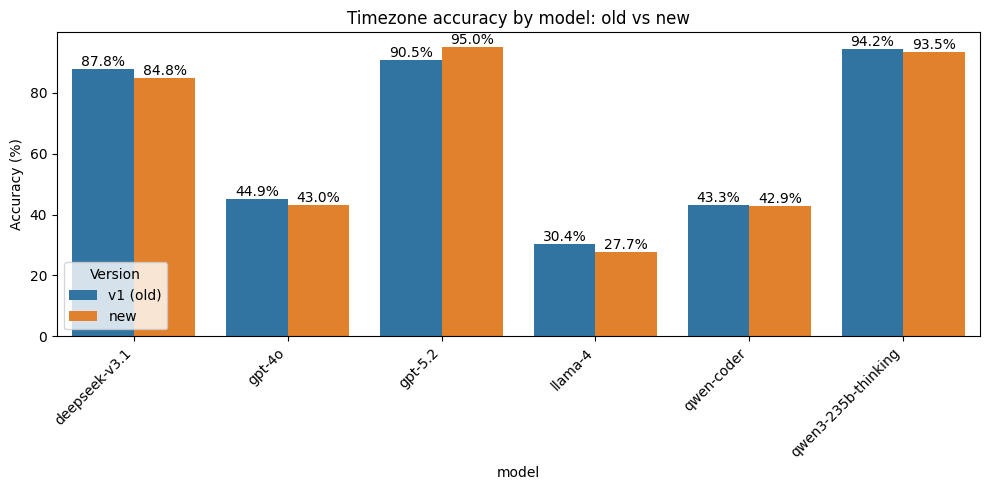

In [19]:
# One plot: each model's accuracy (all conditions combined), old vs new
acc_v1 = df_timezone_v1.groupby("model")["is_correct"].mean().mul(100).reset_index()
acc_v1["version"] = "v1 (old)"
acc_new = df_timezone_new.groupby("model")["is_correct"].mean().mul(100).reset_index()
acc_new["version"] = "new"
acc_compare = pd.concat([acc_v1.rename(columns={"is_correct": "accuracy_%"}), acc_new.rename(columns={"is_correct": "accuracy_%"})], ignore_index=True)

# Optional: only models that appear in both (for fair comparison)
models_both = set(acc_v1["model"]) & set(acc_new["model"])
acc_compare = acc_compare[acc_compare["model"].isin(models_both)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=acc_compare, x="model", y="accuracy_%", hue="version", ci=None, ax=ax)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Timezone accuracy by model: old vs new")
ax.legend(title="Version", loc='lower left')
# add labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
df_timezone_v1['is_correct'] = df_timezone_v1['loss'] == 0.0

df_stats_v1 = df_timezone_v1.groupby(['domain','model','condition'])['is_correct'].mean().mul(100).reset_index(name='accuracy_%')


In [13]:

df_timezone_new['is_correct'] = df_timezone_new['loss'] == 0.0

df_stats_new = df_timezone_new.groupby(['domain','model','condition'])['is_correct'].mean().mul(100).reset_index(name='accuracy_%')
df_stats_new

,domain,model,condition,accuracy_%
0,timezone,deepseek-v3.1,math_only,87.138889
1,timezone,deepseek-v3.1,no_guide,77.796296
2,timezone,deepseek-v3.1,regular,89.361111
3,timezone,gpt-4o,math_only,72.592593
4,timezone,gpt-4o,no_guide,19.842593
5,timezone,gpt-4o,regular,36.527778
6,timezone,gpt-5.2,math_only,99.527778
7,timezone,gpt-5.2,no_guide,85.601852
8,timezone,gpt-5.2,regular,99.916667
9,timezone,llama-4,math_only,78.787037


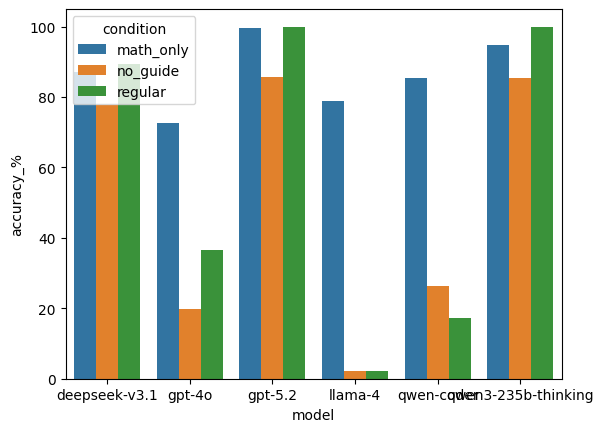

In [14]:
# compare accuracy by model for old vs new

ax = sns.barplot(data=df_stats_new, x='model', y='accuracy_%', hue='condition', ci=None)

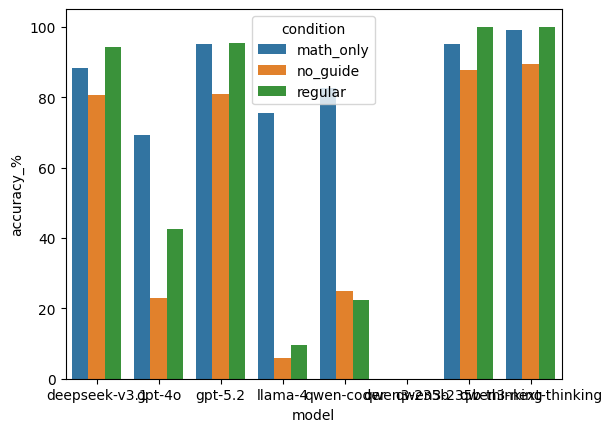

In [15]:
ax = sns.barplot(data=df_stats_v1, x='model', y='accuracy_%', hue='condition', ci=None)